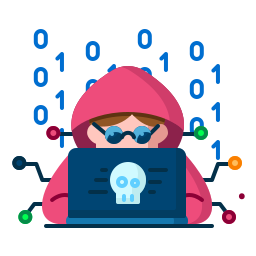

**Attention, all aspiring Python learners and coding clinicians! Welcome to our Python Quiz!** 

If you’re already familiar with how Jupyter Notebook works, you can skip these pointers and jump straight to the quiz. 
But if this is your first time using Jupyter Notebook, then keep the following in mind:
*   Ensure the kernel is running and connected. The top-right corner should display “Idle” with a white circle (⚪), meaning it’s ready to execute code.
*   To run cells, press SHIFT + ENTER. Or simply Run button ▶️ in the toolbar

# 🐍 Python Quiz — Intermediate Level

**Topics:** Data Visualization · Lists & Dictionaries · String Processing

---

## 📋 Session Overview (1 Hour)

| Phase | Duration | Content |
|---|---|---|
| Concept Introduction | 15 min | Key ideas + tool walkthrough |
| Hands-on Exercises | 30 min | 4 guided coding exercises |
| Discussion & Challenges | 15 min | Review answers + bonus tasks |

---

## 🗂️ Our Dataset: 30 Movies

All four exercises today use **the same dataset** — a simulated record of 30 movies, each with:
- `box_office` — worldwide box office in millions USD
- `ratings` — audience rating out of 10
- `reviews` — a short critic snippet

We'll explore this dataset step by step, the same way a real analyst would:

> **① Histogram** → see how ratings are distributed  
> **② Dictionary** → group movies into rating tiers  
> **③ Scatter plot** → check if box office relates to rating  
> **④ Text analysis** → find the most common words in critic reviews  

> 💡 **Before you start:** Make sure Matplotlib is installed. If not, run `pip install matplotlib` in your terminal.

In [ ]:
!pip install matplotlib

In [ ]:
# ─── Run this cell first — all exercises depend on this data ────────────────

import matplotlib.pyplot as plt
from collections import Counter

# Worldwide box office in millions USD
box_office = [
     42,  58,  75,  80,  95, 110, 120, 135, 150, 160,
    175, 200, 215, 230, 260, 280, 310, 340, 380, 420,
    460, 510, 560, 600, 650, 720, 800, 880, 950, 1100
]

# Audience rating out of 10
ratings = [
    3.5, 4.0, 4.2, 4.5, 5.0, 5.2, 5.5, 5.8, 6.0, 6.2,
    6.3, 6.5, 6.6, 6.8, 7.0, 7.1, 7.3, 7.5, 7.6, 7.8,
    7.9, 8.0, 8.2, 8.4, 8.5, 8.7, 8.8, 9.0, 9.2, 9.5
]

# Short critic review snippets
reviews = [
    "A visually stunning but emotionally hollow blockbuster.",
    "Brilliant performances elevate a predictable script.",
    "A masterpiece of storytelling and visual craft.",
    "Funny and heartwarming, a crowd-pleaser for all ages.",
    "The plot drags, but the action sequences are thrilling.",
    "A dull and forgettable entry in an otherwise great franchise.",
    "Visually gorgeous with a gripping and emotional story.",
    "Disappointing — the characters feel flat and unconvincing.",
    "An entertaining ride with stunning special effects.",
    "A bold and brilliant film that challenges the audience."
]

print(f"Dataset loaded : {len(ratings)} movies")
print(f"Rating range   : {min(ratings)} – {max(ratings)}")
print(f"Box office range: ${min(box_office)}M – ${max(box_office)}M")

---

## 1. Histogram — How are ratings distributed? 📊

### What is a Histogram?

A histogram groups numbers into **bins** (intervals) and counts how many values fall in each bin. It answers: **"What does this data look like overall?"**

### ⚠️ Why `bins` matters

The number of bins changes what you see. Run the cell below to compare **bins=3** vs **bins=15** on the same data.

In [ ]:
# ─── Concept Demo: Effect of bin count ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ratings, bins=3, color='steelblue', edgecolor='white')
axes[0].set_title('bins=3  (too coarse)')
axes[0].set_xlabel('Audience Rating')
axes[0].set_ylabel('Number of Movies')

axes[1].hist(ratings, bins=15, color='steelblue', edgecolor='white')
axes[1].set_title('bins=15  (more detail)')
axes[1].set_xlabel('Audience Rating')
axes[1].set_ylabel('Number of Movies')

plt.suptitle('Same Data, Different Bins', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("💬 Which plot tells a clearer story? Why?")

### Exercise 1: Plot a Histogram

Implement `plot_rating_histogram(ratings)` following the steps below.

**Steps:**
1. Calculate the mean: `mean = sum(ratings) / len(ratings)`
2. Plot a histogram with `bins=10` using `plt.hist()`
3. Add a vertical dashed red line at the mean using `plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.1f}')`
4. Add axis labels, a title, and call `plt.legend()`

**Expected output:** A histogram with a red dashed line marking the mean rating (~7.0).

In [ ]:
# ─── Exercise 1 ─────────────────────────────────────────────────────────────

def plot_rating_histogram(ratings):
    """
    Plot a histogram of movie ratings with a vertical mean line.
    """
    mean = sum(ratings) / len(ratings)

    # ── Your code here (4–5 lines) ───────────────────────────────────────────





    # ─────────────────────────────────────────────────────────────────────────
    plt.show()


plot_rating_histogram(ratings)

In [ ]:
# ─── Exercise 1: Reference Solution ─────────────────────────────────────────
# ⚠️  Try your own solution first!

def plot_rating_histogram_solution(ratings):
    mean = sum(ratings) / len(ratings)

    plt.figure(figsize=(8, 5))
    plt.hist(ratings, bins=10, color='steelblue', edgecolor='white')
    plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.1f}')
    plt.xlabel('Audience Rating')
    plt.ylabel('Number of Movies')
    plt.title('Distribution of Movie Ratings')
    plt.legend()
    plt.show()

plot_rating_histogram_solution(ratings)

---

## 2. Dictionaries — Group movies into rating tiers 📋

Now that we can see the overall distribution, let's **group the ratings** into meaningful categories.

### Concept Demo: Using a dictionary to count groups

A dictionary lets us map each rating tier to a count. We use `dict.get(key, 0)` to safely increment a counter even when the key doesn't exist yet.

In [ ]:
# ─── Concept Demo: Counting with a dictionary ────────────────────────────────

sample_ratings = [5.5, 7.2, 8.8, 9.1, 6.5, 7.0, 4.5, 8.3]
counts = {}

for r in sample_ratings:
    if r >= 8.0:
        tier = 'Excellent'
    elif r >= 6.5:
        tier = 'Good'
    elif r >= 5.0:
        tier = 'Average'
    else:
        tier = 'Poor'
    counts[tier] = counts.get(tier, 0) + 1   # safely add 1

print("Tier counts:", counts)

### Exercise 2: Count Movies per Rating Tier

Implement `count_rating_tiers(ratings)` following the steps below.

**Steps:**
1. Create an empty dictionary `tiers = {}`
2. Loop through each rating and assign a tier: **Excellent** (≥8.0), **Good** (≥6.5), **Average** (≥5.0), **Poor** (<5.0)
3. Use `tiers[tier] = tiers.get(tier, 0) + 1` to count each tier
4. Return `tiers`

**Expected output:**
```
{'Poor': 4, 'Average': 7, 'Good': 10, 'Excellent': 9}
```

In [ ]:
# ─── Exercise 2 ─────────────────────────────────────────────────────────────

def count_rating_tiers(ratings):
    """
    Count how many movies fall in each rating tier.
    Returns a dictionary like {'Excellent': 10, 'Good': 10, 'Average': 6, 'Poor': 4}
    """
    # ── Your code here (5–7 lines) ───────────────────────────────────────────





    # ─────────────────────────────────────────────────────────────────────────


# Test
result = count_rating_tiers(ratings)
print(result)
print(f"Total movies accounted for: {sum(result.values())}")

In [ ]:
# ─── Exercise 2: Reference Solution ─────────────────────────────────────────

def count_rating_tiers_solution(ratings):
    tiers = {}
    for r in ratings:
        if r >= 8.0:
            tier = 'Excellent'
        elif r >= 6.5:
            tier = 'Good'
        elif r >= 5.0:
            tier = 'Average'
        else:
            tier = 'Poor'
        tiers[tier] = tiers.get(tier, 0) + 1
    return tiers

result = count_rating_tiers_solution(ratings)
print(result)
print(f"Total movies accounted for: {sum(result.values())}")

---

## 3. Scatter Plot — Does box office relate to rating? 📈

We now know how ratings are distributed and how many movies fall in each tier. The natural next question is: **do higher-rated movies make more money?**

A scatter plot lets us see the relationship between two numerical variables at a glance.

### Concept Demo: Basic scatter plot

In [ ]:
# ─── Concept Demo: Basic scatter plot ───────────────────────────────────────

x = [1, 2, 3, 4, 5]
y = [10, 25, 20, 40, 35]

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='steelblue', s=80)   # s = dot size
plt.xlabel('X values')
plt.ylabel('Y values')
plt.title('Basic Scatter Plot')
plt.show()

### Exercise 3: Plot Rating vs Box Office

Implement `plot_rating_vs_boxoffice(ratings, box_office)` following the steps below.

**Steps:**
1. Call `plt.scatter(ratings, box_office)` to plot the points
2. Set `xlabel` to `'Audience Rating'` and `ylabel` to `'Box Office (million USD)'`
3. Add a title: `'Rating vs Box Office'`

**Bonus (optional):** Color each dot by tier — `'crimson'` for ratings below 5.0, `'steelblue'` for the rest.

**Expected output:** A scatter plot showing a general upward trend.

In [ ]:
# ─── Exercise 3 ─────────────────────────────────────────────────────────────

def plot_rating_vs_boxoffice(ratings, box_office):
    """
    Scatter plot of audience ratings (x) vs box office revenue (y).
    """
    # ── Your code here (3–4 lines) ───────────────────────────────────────────




    # ─────────────────────────────────────────────────────────────────────────
    plt.show()


plot_rating_vs_boxoffice(ratings, box_office)

In [ ]:
# ─── Exercise 3: Reference Solution ─────────────────────────────────────────

def plot_rating_vs_boxoffice_solution(ratings, box_office):
    colors = ['crimson' if r < 5.0 else 'steelblue' for r in ratings]

    plt.figure(figsize=(8, 5))
    plt.scatter(ratings, box_office, c=colors, s=80, edgecolors='white', alpha=0.85)
    plt.xlabel('Audience Rating')
    plt.ylabel('Box Office (million USD)')
    plt.title('Rating vs Box Office')
    plt.show()

plot_rating_vs_boxoffice_solution(ratings, box_office)

---

## 4. Text Analysis — What are critics saying? 🔤

Numbers tell part of the story. The critic review snippets contain extra information — let's find out which words appear most often.

### Concept Demo: Counting words with `Counter`

`Counter` from the `collections` module takes any list and returns a dictionary of `{item: count}`. Calling `.most_common(n)` gives you the top-n items.

In [ ]:
# ─── Concept Demo: Counter on a word list ───────────────────────────────────

sample_words = ['good', 'great', 'good', 'excellent', 'good', 'great']
word_counts = Counter(sample_words)

print("All counts :", word_counts)
print("Top 2 words:", word_counts.most_common(2))

### Exercise 4: Find the Most Common Words in Feedback

Implement `analyze_feedback(comments)` following the steps below.

**Steps:**
1. Join all comments into one string and convert to lowercase: `' '.join(comments).lower()`
2. Split into words by replacing punctuation — use `text.split()` for a simple split, or `re.findall(r'[a-z]+', text)` for a cleaner result (removes punctuation automatically)
3. Count word frequencies using `Counter(words)`
4. Get the top 8 words with `.most_common(8)`
5. Print each word and its count

**Expected output:**
```
a              : 5
and            : 4
stunning       : 2
...
```

In [10]:
# ─── Exercise 4 ─────────────────────────────────────────────────────────────
import re

def analyze_feedback(comments):
    """
    Find and print the 8 most frequent words across all feedback comments.
    """
    # ── Your code here (4–5 lines) ───────────────────────────────────────────





    # ─────────────────────────────────────────────────────────────────────────


analyze_feedback(reviews)

In [ ]:
# ─── Exercise 4: Reference Solution ─────────────────────────────────────────

def analyze_feedback_solution(comments):
    combined = ' '.join(comments).lower()
    words = re.findall(r'[a-z]+', combined)
    top8 = Counter(words).most_common(8)
    for word, count in top8:
        print(f"{word:15s}: {count}")

analyze_feedback_solution(reviews)

---

## 🏁 Bonus Challenges

Finished early? Pick one:

**B1 — Filter blockbusters**  
Write a function `blockbusters(box_office, threshold=500)` that returns only the box office values above the threshold using a list comprehension.

**B2 — Rating tier bar chart**  
Use the result from Exercise 2 to draw a bar chart with `plt.bar()`. Label each bar with the movie count.

**B3 — Flag negative reviews**  
Write a function that checks each review for words like `'disappointing'`, `'dull'`, or `'hollow'`, and prints the index and review text for any matches.

**B4 — Side-by-side plots**  
Use `plt.subplots(1, 2)` to show the histogram (Ex 1) and scatter plot (Ex 3) side by side in one figure.

---

## 📝 Session Recap

| Exercise | Question we asked | Key tool |
|---|---|---|
| 1 — Histogram | How are ratings distributed? | `plt.hist()`, `plt.axvline()` |
| 2 — Dictionary | How many movies per rating tier? | `dict.get()`, `for` loop |
| 3 — Scatter plot | Does rating relate to box office? | `plt.scatter()` |
| 4 — Text analysis | What words appear in reviews? | `Counter`, `re.findall()` |

> 💡 **The bigger picture:** Today you explored one dataset from four different angles. This step-by-step approach — distribution → grouping → relationships → text — is the foundation of real-world exploratory data analysis (EDA).